# 2. The fall edges past chance: is it big enough, in rupees against what a fix costs, to act on?

**Week 1, Thursday. Chapter 2 of 6.** Chapter 1 flipped each of the same 22 Retail-Plus members'
two quarters 5,000 times and found their fall, Rs 1,110 a member, borderline against chance: 145
flips in 5,000 (0.029) made a fall that large and 286 (0.057) a move that large either way. This
chapter sizes that fall in rupees against the tier, the company and the cost of a fix. It adds two
helpers: `delivered`, a segment's revenue in a quarter, and `bootstrap_gaps`, which redraws the
members' own differences to give the range the second route reads.

> **The client asks.** "So my tier really is slipping. What do I get to fix it?"
>
> The head of Retail-Plus, before the growth review

**Who needs the answer.** The head of Retail-Plus wants a retention budget, and Meera weighs it
against every other line in the quarter. A wrong call funds an offer that cannot pay back, or
ignores a fall that keeps draining the tier.

**The questions on the way.**

1. Which of four ways to answer "worth acting on?" can Monday use?
2. How much is the fall in rupees, per member and for the tier?
3. How big is the fall against the company's quarter?
4. Should the smallest share open the growth review?
5. What must a Rs 500 retention offer win back to pay for itself?
6. How small could the fall really be?

**The metric at stake.** The same delivered revenue per member, multiplied out to rupees a quarter
for the tier and set beside the company's quarter and the cost of a fix.

**Who else faces it.** At Microsoft, a small change to how Bing showed ad headlines raised revenue
by 12 percent, more than 100 million dollars a year in the United States alone (Kohavi and Thomke,
Harvard Business Review, 2017), while the company's own researchers found that only about a third
of experiments built to improve a metric did improve it (Kohavi and colleagues, 2009; both checked
30 September 2026).

**Setup.** The toolkit from chapter 1, plus the two new helpers.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import itertools
import random
import statistics

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, members always in the same order."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def flip_gaps(q1, q2, times, seed):
    """The same members measured twice: a coin per member decides which of its two quarters is Q1."""
    random.seed(seed)                              # the same coins on every laptop
    diffs = [a - b for a, b in zip(q1, q2)]        # each member's own Q1 less Q2
    gaps = []
    for _ in range(times):
        flipped = [d if random.random() < 0.5 else -d for d in diffs]   # heads keeps, tails swaps
        gaps.append(mean(flipped))
    return gaps


def shuffle_gaps(q1, q2, times, seed):
    """Two groups of different customers: deal every value to two piles at random, many times."""
    random.seed(seed)
    pool = q1 + q2                                 # all the values, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)                       # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """Counting one direction: the share of chance-only worlds with a gap at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def share_either(gaps, real):
    """Counting either direction: the share of chance-only worlds with a gap that large, up or down."""
    return sum(1 for g in gaps if abs(g) >= abs(real)) / len(gaps)


def delivered(segment, quarter):
    """A segment's delivered revenue in one quarter, in rupees."""
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


def bootstrap_gaps(q1, q2, times, seed):
    """The same members twice: redraw the members' own Q1 less Q2 differences with replacement."""
    random.seed(seed)
    diffs = [a - b for a, b in zip(q1, q2)]
    return [mean([random.choice(diffs) for _ in diffs]) for _ in range(times)]

plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
real = mean(plus_q1) - mean(plus_q2)
print(f"{len(plus_q1)} Retail-Plus members; gap Rs {real:,.0f} per member, carried from chapter 1")

22 Retail-Plus members; gap Rs 1,110 per member, carried from chapter 1


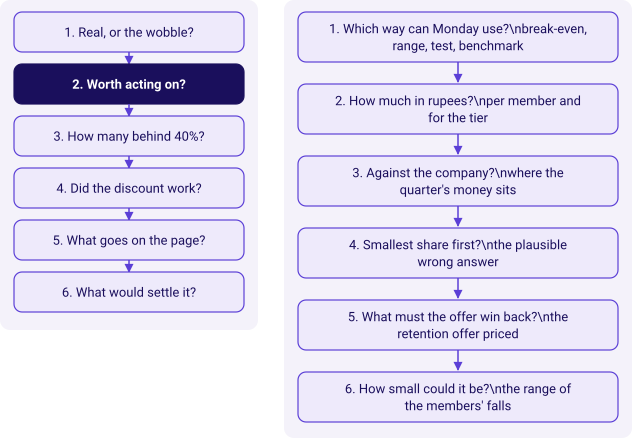

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the wobble?', 'Worth acting on?', 'How many behind 40%?', 'Did the discount work?', 'What goes on the page?', 'What would settle it?'], lit=1, show=False),
    kit.vflow(['1. Which way can Monday use?\\nbreak-even, range, test, benchmark', '2. How much in rupees?\\nper member and for the tier', "3. Against the company?\\nwhere the quarter's money sits", '4. Smallest share first?\\nthe plausible wrong answer', '5. What must the offer win back?\\nthe retention offer priced', "6. How small could it be?\\nthe range of the members' falls"], show=False),
)

## 1. Which of four ways to answer "worth acting on?" can Monday use?

Four ways a team could answer "is it worth acting on?". Each one reaches a decision by a different
kind of evidence.

| Option | What it does | What it needs |
|---|---|---|
| A. Break-even on the estimate | The fall in rupees beside the company's quarter and the offer's cost, and the share of the fall the offer must win back | One pass over the orders, and a cost, assumed today |
| B. The low end of a range | Redraw the members' own falls many times and ask whether even a small plausible fall clears the cost | A loop, and a reader who takes a range |
| C. Test the offer on half the tier | Offer it to a coin-chosen half for a quarter and hold back the other half | Money, a quarter's wait, and enough members a side |
| D. A past offer's recovery rate | Read what an earlier retention offer won back | A measured rate, which Kalpa does not have |

Option,What it stands on,What it assumes,What it risks
A. Break-even on the estimate,"186 orders, one pass","the Rs 1,110 per member is the true fall",a fall that is really smaller turns a paying offer into a loss
B. The low end of a range,"22 differences x 5,000 redraws",22 members stand for the tier,a rough low end: it moves by Rs 85 across five seeds
C. Test the offer on half,"11 members a side, Rs 5,500 a quarter","a coin picks the half, so the halves start alike","a quarter's wait, and eleven a side can show only a large recovery"
D. A past offer's rate,a recovery measured on an earlier offer,that offer's members were like these,"no Kalpa offer has been measured, so it cannot run today"


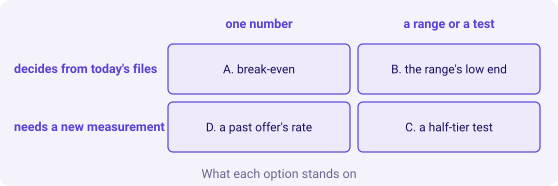

In [3]:
offer_per_member = 500                                   # assumed for the chapter; no Kalpa figure exists
tier_cost = offer_per_member * len(plus_q1)
half_cost = offer_per_member * (len(plus_q1) // 2)
low_ends = [sorted(bootstrap_gaps(plus_q1, plus_q2, 5000, seed=s))[125] for s in (1, 2, 3, 4, 5)]
rows = [
    ("A. Break-even on the estimate", f"{len(ORDERS)} orders, one pass", "the Rs 1,110 per member is the true fall",
     "a fall that is really smaller turns a paying offer into a loss"),
    ("B. The low end of a range", f"{len(plus_q1)} differences x 5,000 redraws", "22 members stand for the tier",
     f"a rough low end: it moves by Rs {max(low_ends) - min(low_ends):,.0f} across five seeds"),
    ("C. Test the offer on half", f"{len(plus_q1) // 2} members a side, {kit.rupees(half_cost)} a quarter",
     "a coin picks the half, so the halves start alike", "a quarter's wait, and eleven a side can show only a large recovery"),
    ("D. A past offer's rate", "a recovery measured on an earlier offer", "that offer's members were like these",
     "no Kalpa offer has been measured, so it cannot run today"),
]
kit.table(["Option", "What it stands on", "What it assumes", "What it risks"], rows,
          caption="The options sized on Kalpa's file by what separates them")
kit.matrix(["decides from today's files", "needs a new measurement"], ["one number", "a range or a test"],
           [["A. break-even", "B. the range's low end"], ["D. a past offer's rate", "C. a half-tier test"]],
           title="What each option stands on")
kit.check("the offer costs Rs 11,000 for the tier and Rs 5,500 for half of it", tier_cost == 11000 and half_cost == 5500)
kit.check("the range's low end moves by under Rs 100 across five seeds", max(low_ends) - min(low_ends) < 100,
          f"Rs {min(low_ends):,.0f} to Rs {max(low_ends):,.0f}")

**The best-fit call: A for Monday's number, with B as the second route.** Meera's decision is a
budget line, so the answer has to be in rupees beside the company's quarter and the offer's cost,
with the share of the fall the offer must win back. B asks whether even a small plausible fall
clears that cost, which is the honest follow-up to a borderline fall. C spends money and a quarter,
so it is where the answer can lead once it is reached. **The fact that would
change the call.** A recovery rate measured on an earlier offer to members like these, which is D:
with it, the break-even alone decides, and the range matters less.

## 2. How much is the fall in rupees, per member and for the tier?

A per-member gap is a rate. The budget holder needs the total: the gap times the members who exist
in both quarters.

**Predict before you run.** Retail-Plus lost Rs 1,110 per member. In total, per quarter, that is
roughly: a) Rs 2,400; b) Rs 24,000; c) Rs 2.4 lakh; d) Rs 24 lakh.

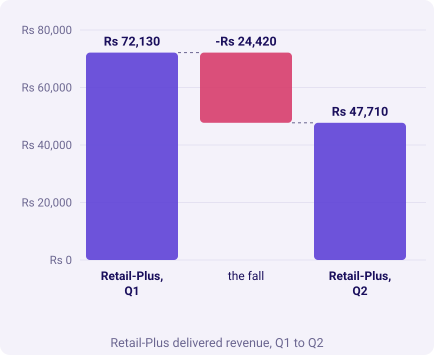

In [4]:
plus_fall = round(real * len(plus_q1))
kit.bridge(("Retail-Plus, Q1", sum(plus_q1)), [("the fall", -plus_fall)], end_label="Retail-Plus, Q2",
           title="Retail-Plus delivered revenue, Q1 to Q2")
kit.stats([(kit.rupees(real), "per member", "Q1 mean less Q2 mean"),
           (f"{len(plus_q1)}", "members", "in both quarters"),
           (kit.rupees(plus_fall), "a quarter", "the segment's fall")])
kit.check("Retail-Plus lost Rs 24,420 of delivered revenue in a quarter", plus_fall == 24420, kit.rupees(plus_fall))

**What happened.** The answer is b. Rs 1,110 times 22 members is Rs 24,420 a quarter: the tier
delivered Rs 72,130 in Q1 and Rs 47,710 in Q2. For the segment that is a third of its money, which is
why the head of Retail-Plus is worried.

## 3. How big is the fall against the company's quarter?

Meera runs the company, so the second size is the fall against the company's delivered revenue,
with every segment's move side by side.

**Predict before you run.** As a share of the company's Q2 delivered revenue, the Retail-Plus fall
is: a) about 30 percent; b) about 3 percent; c) under half of one percent; d) impossible to say
without Business.

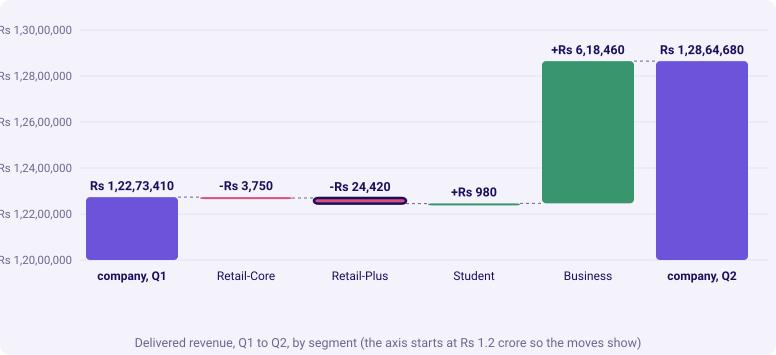

company delivered: Q1 Rs 1,22,73,410, Q2 Rs 1,28,64,680; the Retail-Plus fall is 0.19% of Q2


In [5]:
company_q1 = sum(delivered(s, "Q1") for s in SEGMENTS)
company_q2 = sum(delivered(s, "Q2") for s in SEGMENTS)
moves = [(s, delivered(s, "Q2") - delivered(s, "Q1")) for s in SEGMENTS]
kit.bridge(("company, Q1", company_q1), moves, end_label="company, Q2", lo=12_000_000, lit=[1],
           title="Delivered revenue, Q1 to Q2, by segment (the axis starts at Rs 1.2 crore so the moves show)")
share_of_company = plus_fall / company_q2
print(f"company delivered: Q1 {kit.rupees(company_q1)}, Q2 {kit.rupees(company_q2)}; "
      f"the Retail-Plus fall is {share_of_company:.2%} of Q2")
kit.check("the bridge lands: Q1 plus every segment's move is Q2", company_q1 + sum(m for _, m in moves) == company_q2)
kit.check("the Retail-Plus fall is under half of one percent of the company's Q2", share_of_company < 0.005,
          f"{share_of_company:.2%}")

**What happened.** The answer is c. The company delivered Rs 1,28,64,680 in Q2, and the
Retail-Plus fall is 0.19 percent of it, less than one rupee in five hundred. The fall is borderline
against chance and small against the company; both are true, and the note needs both.

## 4. Should the smallest share open the growth review?

**The plausible wrong answer.** A hurried draft runs the flip test on every segment with enough
members, sorts by the share, and lets the order of the shares set the order of the growth review.
Student waits for chapter 3. The shares count a move that large in either direction, since no
direction was fixed before the quarter was seen.

In [6]:
ranked = []
for s in ["Retail-Core", "Retail-Plus", "Business"]:
    q1, q2 = member_totals(s, "Q1"), member_totals(s, "Q2")
    share = share_either(flip_gaps(q1, q2, 5000, seed=2026), mean(q1) - mean(q2))
    ranked.append((s, share, delivered(s, "Q2") - delivered(s, "Q1")))
by_share = sorted(ranked, key=lambda r: r[1])
for n, (s, share, _) in enumerate(by_share, 1):
    print(f"  {n}. {s:12s} p = {share:.3f}, either way")
print(f"Draft: '{by_share[0][0]} is the surest move of the quarter, so it opens the growth review: fund its retention programme first.'")

  1. Retail-Plus  p = 0.057, either way
  2. Retail-Core  p = 0.723, either way
  3. Business     p = 0.910, either way
Draft: 'Retail-Plus is the surest move of the quarter, so it opens the growth review: fund its retention programme first.'


**Why it is wrong.** The share says how surely a move beats chance. It never says how big the move
is, and the draft ordered the review by the wrong column: the review would open on a borderline fall
of Rs 24,420 and fund a programme because a share was small, before anyone asked where the
quarter's money moved or what the fix costs. **The check** puts the rupees beside the share and
orders the same three segments by money, and an invented example shows why the two columns can
disagree so far: with enough orders, even a trivial gap beats chance.

Segment,"p, either way","Delivered revenue, Q2 less Q1",Place by share,Place by rupees
Retail-Core,0.723,"-Rs 3,750",2,3
Retail-Plus,0.057,"-Rs 24,420",1,2
Business,0.910,"Rs 6,18,460",3,1


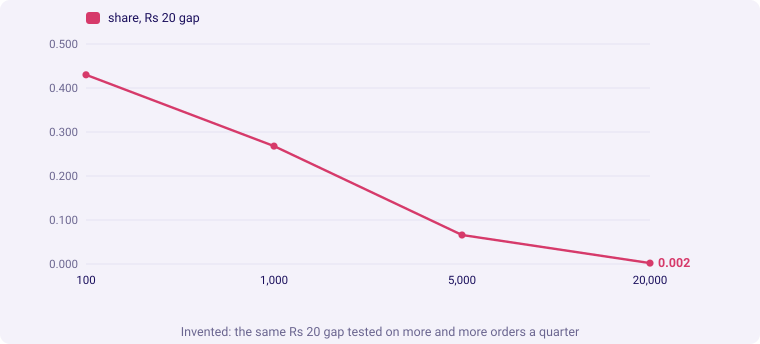

{100: 0.43, 1000: 0.268, 5000: 0.066, 20000: 0.002}


In [7]:
by_money = sorted(ranked, key=lambda r: -abs(r[2]))
kit.table(["Segment", "p, either way", "Delivered revenue, Q2 less Q1", "Place by share", "Place by rupees"],
          [(s, f"{share:.3f}", kit.rupees(move), by_share.index((s, share, move)) + 1, by_money.index((s, share, move)) + 1)
           for s, share, move in ranked],
          caption="The same three segments with the money beside the share")
maker = random.Random(11)                                  # invented orders: two quarters of different orders
base = [maker.randint(1000, 3400) for _ in range(40000)]
sizes, shares = [100, 1000, 5000, 20000], []
for n in sizes:
    later = base[:n]
    earlier = base[20000:20000 + n]
    lift = 20 - (mean(earlier) - mean(later))              # set the earlier quarter exactly Rs 20 above the later one
    earlier = [v + lift for v in earlier]
    shares.append(share_at_least(shuffle_gaps(earlier, later, 500, seed=2026), 20))
kit.line([f"{n:,}" for n in sizes], [("share, Rs 20 gap", shares, "bad")], fmt=lambda v: f"{v:.3f}",
         title="Invented: the same Rs 20 gap tested on more and more orders a quarter")
print(dict(zip(sizes, [round(s, 3) for s in shares])))
kit.check("ordered by share, Retail-Plus comes first; ordered by rupees moved, it does not",
          by_share[0][0] == "Retail-Plus" and by_money[0][0] != "Retail-Plus", f"{by_money[0][0]} leads by rupees")
kit.check("an invented Rs 20 gap goes from chance-sized to significant on sample size alone",
          shares[0] > 0.2 and shares[-1] < 0.01, f"{[round(s, 3) for s in shares]}")

**The fix.** Two sentences where the draft had one, and the review ordered by money: "The
Retail-Plus fall is borderline against chance, about 3 in 100 flips counting falls and 6 in 100
either way. It is worth Rs 24,420 a quarter, 0.19 percent of the company's delivered revenue."
Ordered by rupees moved, Business opens the review and Retail-Plus comes second. Business's rise
does not shrink the Retail-Plus fall: the fall is judged on its own terms, against the company's
quarter and against what the offer costs. What changed: the order of the review and the size of the
claim. The Retail-Plus programme now has to justify itself against Rs 24,420 a quarter and the
offer's cost.

## 5. What must a Rs 500 retention offer win back to pay for itself?

The head of Retail-Plus proposes a retention offer. **The cost is an assumption for this chapter,
since no Kalpa figure exists for it:** Rs 500 per member per quarter, offered to all 22 members.

**Predict before you run.** What share of the Rs 24,420 fall would the offer have to win back just
to pay for itself in revenue? a) all of it; b) about 45 percent; c) about 5 percent; d) none, since
any recovery is a gain.

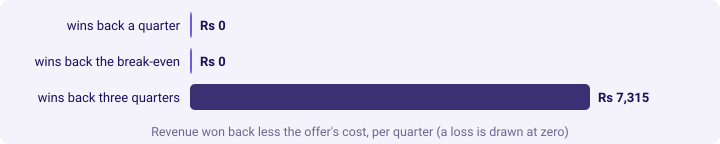

  wins back a quarter        net -Rs 4,895
  wins back the break-even   net Rs 0
  wins back three quarters   net Rs 7,315


In [8]:
offer_cost = tier_cost
break_even = offer_cost / plus_fall
scenarios = [("wins back a quarter", 0.25), ("wins back the break-even", break_even),
             ("wins back three quarters", 0.75)]
kit.bars([(label, max(0, round(plus_fall * r - offer_cost))) for label, r in scenarios], fmt=kit.rupees,
         lit=[2], title="Revenue won back less the offer's cost, per quarter (a loss is drawn at zero)")
for label, r in scenarios:
    print(f"  {label:26s} net {kit.rupees(round(plus_fall * r - offer_cost))}")
kit.check("the offer costs Rs 11,000 a quarter", offer_cost == 11000, kit.rupees(offer_cost))
kit.check("it pays only above a 45 percent recovery", round(break_even, 2) == 0.45, f"{break_even:.3f}")

**What happened.** The answer is b. The offer costs Rs 11,000 a quarter, so it has to win back 45
percent of the fall before it breaks even on revenue. Winning back a quarter loses about Rs 4,900;
winning back three quarters gains about Rs 7,300. The decision rests on a recovery rate nobody has
measured, on a fall that is itself borderline, which is what the note should say.

## 6. How small could the fall really be?

Option B, the second route. The Rs 1,110 is one estimate from 22 members. Redraw the 22 members' own Q1 less Q2
differences with replacement 5,000 times and read the middle 95 percent of the averages. That range
is called a **confidence interval**; how to build one properly is a later week's topic, and today it
arrives as a picture.

**Predict before you run.** Where does the range's low end sit, against zero and against the
offer's Rs 500 per member? a) above both; b) just above zero, and far below Rs 500; c) below zero,
so the fall cannot be real; d) exactly Rs 1,110 every time.

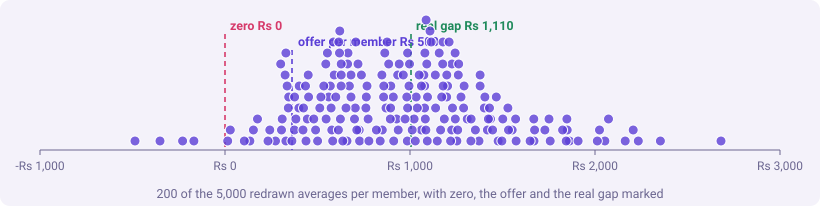

middle 95 percent: Rs 81 to Rs 2,164 per member, or Rs 1,780 to Rs 47,610 a quarter; share at or below zero 0.016


In [9]:
boot = bootstrap_gaps(plus_q1, plus_q2, 5000, seed=2026)
ordered = sorted(boot)
low, high = ordered[125], ordered[4874]
at_or_below_zero = sum(1 for g in boot if g <= 0) / len(boot)
kit.strip(boot[:200], markers=[("zero", 0, "bad"), ("offer per member", offer_per_member, "plain"),
                               ("real gap", real, "good")], lo=-1000, hi=3000,
          title="200 of the 5,000 redrawn averages per member, with zero, the offer and the real gap marked")
print(f"middle 95 percent: Rs {low:,.0f} to Rs {high:,.0f} per member, "
      f"or {kit.rupees(low * 22)} to {kit.rupees(high * 22)} a quarter; share at or below zero {at_or_below_zero:.3f}")
kit.check("the range's low end sits above zero and far below the offer's Rs 500 a member", 0 < low < offer_per_member / 2, f"Rs {low:,.0f}")
kit.check("consistency: the share of redraws at or below zero sits within 0.02 of the flips' falls-only 0.029",
          abs(at_or_below_zero - 0.029) < 0.02, f"{at_or_below_zero:.3f}")

**What happened.** The answer is b. This approximate 95 percent range runs from about Rs 80 to Rs
2,160 per member, and its low end moves between about Rs 15 and Rs 100 with the seed, so it sits
close to zero; under 2 in 100 redraws land at or below zero, a consistency check beside the flips'
0.029 rather than a second p-value. At its low end the fall is about Rs 1,780 a quarter for the whole
tier. The offer's Rs 500 per member sits far above that low end, which is the arithmetic behind
"worth watching, and not worth acting on alone": if the head of Retail-Plus wants to act, the cheap
way is the offer on a coin-chosen half. **When to switch.** Read the range whenever the decision has
a cost to beat; the share alone is enough only when the question is "real or not".

Kavya Nair, the team's senior analyst, reads every answer before it leaves the team.

> **Kavya's review.** "Borderline against chance by two routes, worth Rs 24,420 a quarter, 0.19
> percent of the company and a third of the tier. The range's low end sits far below what the offer
> costs, so this is a watch item. If the head of Retail-Plus wants to act, offer it to a coin-chosen
> half and hold back the other half, knowing that eleven members a side will show only a large
> recovery."

### In the interview: a metric moved and the test says significant; should the business act?

**[F] A metric moved and the test says significant; how do you decide whether the business should
act?** "Significant only tells me the move is bigger than noise, and here it is borderline. To act
I need three more things: the size in money against the business and the segment, the cost of the
action, and how much of the gap the action could recover. If the break-even recovery is higher than
anything we have seen, or the range of the effect dips below the cost, I recommend a small test with
a held-back group rather than a rollout."

**[S] Explain a finding to a non-technical stakeholder.** "I lead with the decision the finding
supports, in one sentence, with one number and its denominator. Then the evidence, the caveat that
would change my view, and the action with what it costs. For example: Retail-Plus is spending less
by a borderline amount, Rs 24,420 a quarter, which is a third of the tier and 0.19 percent of the
company; an offer pays only if it wins back 45 percent, so we watch it, and if we act
we test on half the members first."

**[D] Break-even, a range, a test on half the tier, or a past offer's recovery rate: which do you
take to the budget meeting, and what would change it?** "The break-even on the estimate, checked
against the low end of the range, because the meeting decides money and the range says how small
the fall could be. The half-tier test is what I recommend if they want to act. A measured recovery
rate from an earlier offer would let the break-even decide alone."

### Depth: what must the offer win back once Kalpa's margin counts?

The break-even above compares the offer with revenue won back. Kalpa keeps only its margin on that
revenue, so the true break-even is higher. **The margin is an assumption for the depth section,
since no Kalpa margin figure exists:** at 30 percent, the offer would have to win back more than the
whole fall.

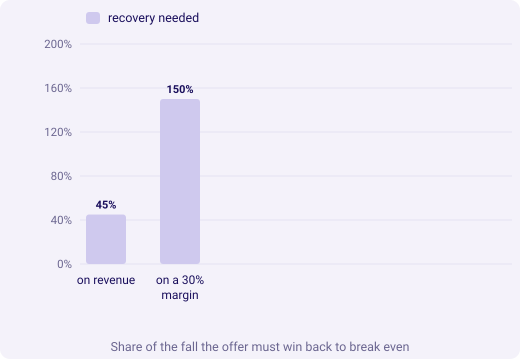

In [10]:
assumed_margin = 0.30                                    # assumed; no Kalpa figure exists
margin_break_even = offer_cost / (plus_fall * assumed_margin)
kit.columns(["on revenue", "on a 30% margin"], [("recovery needed", [round(break_even * 100), round(margin_break_even * 100)])],
            fmt=lambda v: f"{v:.0f}%", width=520, title="Share of the fall the offer must win back to break even")
kit.check("on an assumed 30 percent margin the offer cannot pay back from this fall", margin_break_even > 1,
          f"{margin_break_even:.0%}")

## So is the fall big enough, in rupees against what a fix costs, to act on?

1. Break-even on the estimate, with the range as its check; a recovery rate measured on an earlier
   offer would let the break-even decide alone.
2. Rs 1,110 a member times 22 members is Rs 24,420 a quarter, a third of the tier's Q1 money
   (Rs 72,130 in Q1 against Rs 47,710 in Q2).
3. It is 0.19 percent of the company's Q2 delivered revenue of Rs 1,28,64,680.
4. No: ordered by rupees moved, Business opens the review with a rise of Rs 6,18,460, and an
   invented Rs 20 gap falls from 0.43 to 0.002 on sample size alone.
5. 45 percent of the fall: the assumed offer costs Rs 11,000 a quarter against a Rs 24,420 fall,
   and on an assumed 30 percent margin it would need 150 percent.
6. As small as about Rs 80 a member: the approximate 95 percent range runs from about Rs 80 to
   Rs 2,160, and 0.016 of the redraws land at or below zero.

The fall is worth watching, and not worth acting on alone. If the head of Retail-Plus wants to act,
the offer goes to a coin-chosen half of the tier first, Rs 5,500 a quarter, and eleven members a side
can show only a large recovery.

In [11]:
kit.check_summary()
print("Next: chapter 3. Student is up 40 percent; how many orders stand behind it?")

Next: chapter 3. Student is up 40 percent; how many orders stand behind it?
